In [59]:
import pandas as pd
import numpy as np

#### Load data

In [ ]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

#### Visualize data

In [118]:
cat_col = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]
num_col = list(train_data.columns.drop(cat_col + ["price_range"]))
print(len(cat_col), len(num_col))

6 14


array([[<Axes: xlabel='price_range', ylabel='price_range'>,
        <Axes: xlabel='battery_power', ylabel='price_range'>,
        <Axes: xlabel='clock_speed', ylabel='price_range'>,
        <Axes: xlabel='fc', ylabel='price_range'>,
        <Axes: xlabel='int_memory', ylabel='price_range'>,
        <Axes: xlabel='m_dep', ylabel='price_range'>,
        <Axes: xlabel='mobile_wt', ylabel='price_range'>,
        <Axes: xlabel='n_cores', ylabel='price_range'>,
        <Axes: xlabel='pc', ylabel='price_range'>,
        <Axes: xlabel='px_height', ylabel='price_range'>,
        <Axes: xlabel='px_width', ylabel='price_range'>,
        <Axes: xlabel='ram', ylabel='price_range'>,
        <Axes: xlabel='sc_h', ylabel='price_range'>,
        <Axes: xlabel='sc_w', ylabel='price_range'>,
        <Axes: xlabel='talk_time', ylabel='price_range'>],
       [<Axes: xlabel='price_range', ylabel='battery_power'>,
        <Axes: xlabel='battery_power', ylabel='battery_power'>,
        <Axes: xlabel='clock_sp

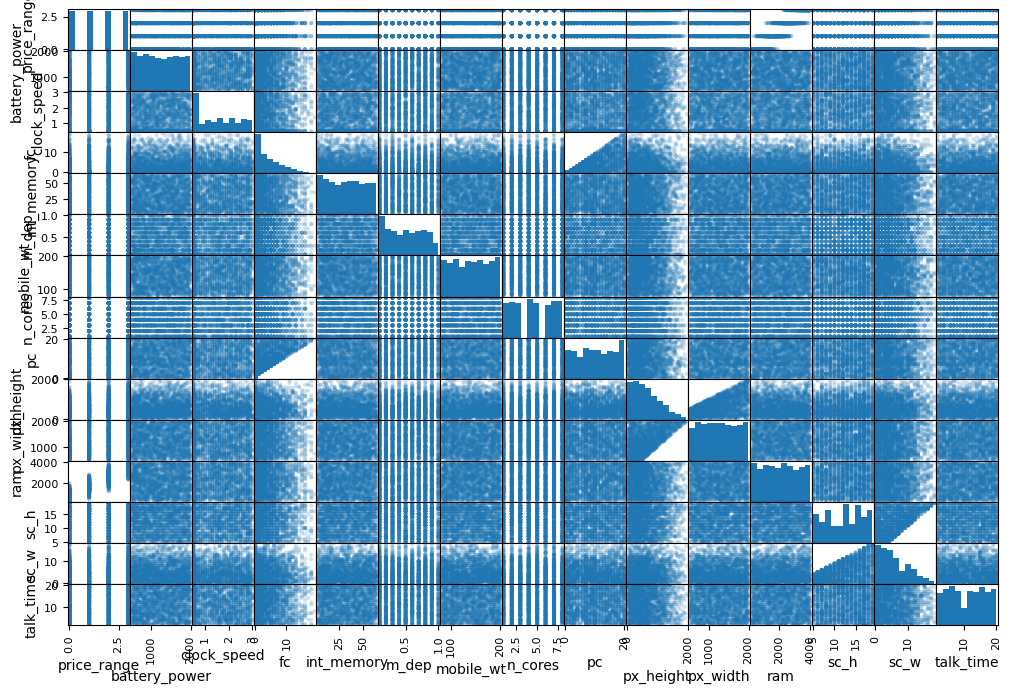

In [120]:
from pandas.plotting import scatter_matrix
scatter_matrix(train_data[["price_range"] + num_col], figsize=(12, 8), alpha=.2)

In [87]:
train_data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [86]:
X_all = train_data.copy()
X_all["px_area"] = X_all["px_width"] * X_all["px_height"]
X_all["sc_area"] = X_all["sc_w"] * X_all["sc_h"]

X_all.corr()["price_range"].sort_values(ascending=False)

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_area          0.176240
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_area          0.041248
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [76]:
np.argmax(X_all["px_sc_area_ratio"])
X_all[X_all["sc_w"]==0]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,px_area,sc_area,px_sc_area_ratio
12,1815,0,2.8,0,2,0,33,0.6,159,4,...,18,0,2,1,0,0,1,454036,0,inf
24,503,0,1.2,1,5,1,8,0.4,111,3,...,11,0,12,1,0,0,1,250245,0,inf
33,1310,1,2.2,1,0,1,51,0.6,100,4,...,7,0,12,1,1,0,3,341582,0,inf
42,1253,1,0.5,1,5,1,5,0.2,152,2,...,15,0,4,1,1,0,1,489090,0,inf
50,1547,1,3.0,1,2,1,14,0.7,198,3,...,5,0,15,1,0,1,2,1908944,0,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1918,772,0,1.0,1,0,1,23,0.6,97,7,...,7,0,17,1,0,0,2,572185,0,inf
1920,591,1,0.5,1,1,1,16,0.9,90,6,...,5,0,5,1,1,0,3,1429876,0,inf
1946,590,1,1.2,1,0,0,32,0.4,141,6,...,10,0,6,0,1,0,0,115543,0,inf
1954,686,1,2.7,1,0,0,36,0.1,194,4,...,10,0,13,0,0,0,0,47680,0,inf


array([[<Axes: xlabel='price_range', ylabel='price_range'>,
        <Axes: xlabel='ram', ylabel='price_range'>,
        <Axes: xlabel='px_area', ylabel='price_range'>,
        <Axes: xlabel='px_width', ylabel='price_range'>,
        <Axes: xlabel='px_height', ylabel='price_range'>],
       [<Axes: xlabel='price_range', ylabel='ram'>,
        <Axes: xlabel='ram', ylabel='ram'>,
        <Axes: xlabel='px_area', ylabel='ram'>,
        <Axes: xlabel='px_width', ylabel='ram'>,
        <Axes: xlabel='px_height', ylabel='ram'>],
       [<Axes: xlabel='price_range', ylabel='px_area'>,
        <Axes: xlabel='ram', ylabel='px_area'>,
        <Axes: xlabel='px_area', ylabel='px_area'>,
        <Axes: xlabel='px_width', ylabel='px_area'>,
        <Axes: xlabel='px_height', ylabel='px_area'>],
       [<Axes: xlabel='price_range', ylabel='px_width'>,
        <Axes: xlabel='ram', ylabel='px_width'>,
        <Axes: xlabel='px_area', ylabel='px_width'>,
        <Axes: xlabel='px_width', ylabel='px_widt

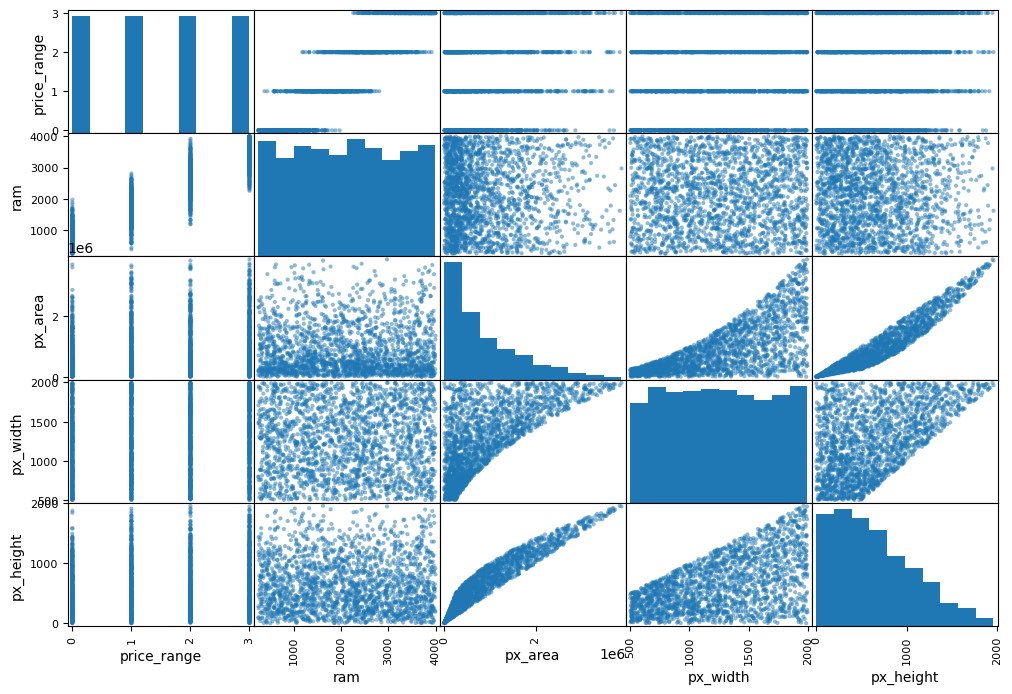

In [ ]:
from pandas.plotting import scatter_matrix
scatter_matrix(X_all[["price_range", "ram", "px_area", "px_width", "px_height"]], figsize=(12, 8))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_all.drop("price_range", axis=1), X_all["price_range"])

In [ ]:
from sklearn.impute import KNNImputer

In [54]:
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

sv_clf = SVC(random_state=42)
sgd_clf = SGDClassifier(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)

sv_clf.fit(X_train, y_train)
sgd_clf.fit(X_train, y_train)
rnd_clf.fit(X_train, y_train)

ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values